***

## DL & GEN AI - 28th July 2026

## PRACTICAL 3 : CNN - MNIST DATA

***

# CNN Workflow

MNIST image  
→ Convolution  
→ ReLU  
→ Max Pooling  
→ Convolution  
→ ReLU  
→ Max Pooling  
→ Flatten  
→ Dense Layer  
→ Ten-Class Output

In [45]:
# Run this command only when TensorFlow is not already installed.
# In Google Colab, TensorFlow is normally available.

# %pip install -q tensorflow matplotlib pandas

%pip install --upgrade "protobuf>=6.31.1,<7"

%pip check

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


mlflow 3.3.2 has requirement pandas<3, but you have pandas 3.0.2.
mlflow-skinny 3.3.2 has requirement packaging<26, but you have packaging 26.2.
mlflow-tracing 3.3.2 has requirement packaging<26, but you have packaging 26.2.
pgmpy 1.1.0 has requirement numpy>=2.0, but you have numpy 1.26.4.
streamlit 1.47.0 has requirement packaging<26,>=20, but you have packaging 26.2.
streamlit 1.47.0 has requirement pandas<3,>=1.4.0, but you have pandas 3.0.2.
streamlit 1.47.0 has requirement pillow<12,>=7.1.0, but you have pillow 12.3.0.
tensorflow-intel 2.17.0 has requirement protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 6.33.6.
mdit-py-plugins 0.3.0 has requirement markdown-it-py<3.0.0,>=1.0.0, but you have markdown-it-py 3.0.0.
pyopenssl 24.0.0 has requirement cryptography<43,>=41.0.5, but you have cryptography 45.0.6.
spyder 5.5.1 has requirement ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.4.0.
spyder-

In [46]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
import google.protobuf
from tensorflow.keras import layers,models

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.17.0


## 1] load the MNIST dataset

### - the MNIST contains grayscale images of handwritten digits from 0 to 9.

Each image has:
* height = 28 pixels
* width = 28 pixels
* channels = 1


In [47]:
(x_train_full, y_train_full), (x_test, y_test) = ( tf.keras.datasets.mnist.load_data())

print("Original training images:", x_train_full.shape)
print("Original training labels:", y_train_full.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
print("Pixel-value range:", x_train_full.min(), "to", x_train_full.max())

Original training images: (60000, 28, 28)
Original training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel-value range: 0 to 255


## 2] use a smaller subset for a quick demonstration

#### - a smaller subset reduces training time while preserving the complete CNN workflow.

* training images: 10000
* validation images: 2000
* test images: 3000

In [48]:
# Shuffle the original training set reproducibly.

indices = np.random.permutation(len(x_train_full))
x_train_full = x_train_full[indices]
y_train_full = y_train_full[indices]

x_train = x_train_full[:10000]
y_train = y_train_full[:10000]

x_validation = x_train_full[10000:12000]
y_validation = y_train_full[10000:12000]

x_test = x_test[:3000]
y_test = y_test[:3000]

split_table = pd.DataFrame({
    "Dataset split": ["Training", "Validation", "Testing"],
    "Images": [len(x_train), len(x_validation), len(x_test)],
    "Image shape": [
        str(x_train.shape[1:]),
        str(x_validation.shape[1:]),
        str(x_test.shape[1:])
    ]
})

display(split_table)

,Dataset split,Images,Image shape
0,Training,10000,"(28, 28)"
1,Validation,2000,"(28, 28)"
2,Testing,3000,"(28, 28)"


## 3] visualize sample images

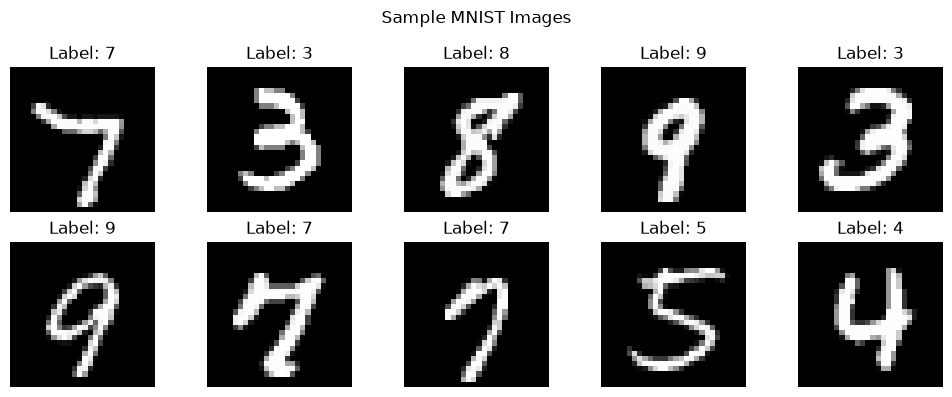

In [49]:
plt.figure(figsize=(10, 4))

for position in range(10):
    plt.subplot(2, 5, position + 1)
    plt.imshow(x_train[position], cmap="gray")
    plt.title(f"Label: {y_train[position]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

## 4] normalize and reshape the images

In [50]:
x_train = x_train.astype("float32") / 255.0
x_validation = x_validation.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_validation = np.expand_dims(x_validation, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training tensor shape:", x_train.shape)
print("Validation tensor shape:", x_validation.shape)
print("Testing tensor shape:", x_test.shape)
print("Normalized pixel range:", x_train.min(), "to", x_train.max())

Training tensor shape: (10000, 28, 28, 1)
Validation tensor shape: (2000, 28, 28, 1)
Testing tensor shape: (3000, 28, 28, 1)
Normalized pixel range: 0.0 to 1.0


## 5] construct the CNN

#### - Architecture: Input: 28 × 28 × 1

1. Conv2D: 16 filters of size 3 × 3
2. MaxPooling2D: 2 × 2
3. Conv2D: 32 filters of size 3 × 3
4. MaxPooling2D: 2 × 2
5. Flatten
6. Dense: 32 neurons
7. Output: 10 neurons with Softmax


In [51]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="Convolution_1"
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2),
        name="MaxPool_1"
    ),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="Convolution_2"
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2),
        name="MaxPool_2"
    ),

    layers.Flatten(name="Flatten"),
    layers.Dense(
        32,
        activation="relu",
        name="Dense_Hidden"
    ),
    layers.Dense(
        10,
        activation="softmax",
        name="Output"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Convolution_1 (Conv2D)               │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MaxPool_1 (MaxPooling2D)             │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Convolution_2 (Conv2D)               │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MaxPool_2 (MaxPooling2D)             │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Flatten (Flatten)                    │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_Hidden (Dense)                 │ (None, 32)                  │          50,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,338 (216.16 KB)

 Trainable params: 55,338 (216.16 KB)

 Non-trainable params: 0 (0.00 B)

## 6] layer sizes and parameter counts

#### - Parameter formulas

*For a convolutional layer:*

Parameters = (kernel height × kernel width × input channels + 1) × filters

*For a dense layer:*

Parameters = (input units + 1) × output units

The extra 1 represents the bias.


In [52]:
layer_rows = []

for layer in model.layers:
    layer_rows.append({
        "Layer": layer.name,
        "Layer type": layer.__class__.__name__,
        "Output shape": str(tuple(layer.output.shape)),
        "Parameters": layer.count_params()
    })

layer_table = pd.DataFrame(layer_rows)

display(layer_table)

print("Total trainable parameters:", model.count_params())


,Layer,Layer type,Output shape,Parameters
0,Convolution_1,Conv2D,"(None, 28, 28, 16)",160
1,MaxPool_1,MaxPooling2D,"(None, 14, 14, 16)",0
2,Convolution_2,Conv2D,"(None, 14, 14, 32)",4640
3,MaxPool_2,MaxPooling2D,"(None, 7, 7, 32)",0
4,Flatten,Flatten,"(None, 1568)",0
5,Dense_Hidden,Dense,"(None, 32)",50208
6,Output,Dense,"(None, 10)",330


Total trainable parameters: 55338


### manaul parameter calculation:

* Convolution 1: (3 × 3 × 1 + 1) × 16 = 160
* Convolution 2: (3 × 3 × 16 + 1) × 32 = 4,640
* Dense hidden layer: (1,568 + 1) × 32 = 50,208
* Output layer: (32 + 1) × 10 = 330

Total parameters = 55,338

## 7] compile the CNN

* Adam updates the parameters.
* Sparse categorical cross-entropy is used because class labels are integers from 0 to 9.
* Accuracy measures the proportion of correct classifications.

In [53]:
model.compile( optimizer = "adam",
             loss = "sparse_categorical_crossentropy",
             metrics = ["accuracy"])

print("model compiled successfully.")

model compiled successfully.


## 8] train the CNN

In [54]:
#The network is trained for three epochs to keep the practical short.

history = model.fit(
    x_train, y_train,
    validation_data=(x_validation, y_validation),
    epochs=30, batch_size=64, verbose=1
)


Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6229 - loss: 1.2176 - val_accuracy: 0.9215 - val_loss: 0.2755
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9322 - loss: 0.2334 - val_accuracy: 0.9415 - val_loss: 0.1840
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9588 - loss: 0.1425 - val_accuracy: 0.9555 - val_loss: 0.1368
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9699 - loss: 0.1049 - val_accuracy: 0.9670 - val_loss: 0.1106
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9766 - loss: 0.0812 - val_accuracy: 0.9705 - val_loss: 0.0997
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9821 - loss: 0.0656 - val_accuracy: 0.9705 - val_loss: 0.0977
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9832 - loss: 0.0545 - val_accuracy: 0.9720 - val_loss: 0.1005
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9863 - loss: 0.0473 - val_accuracy:

## 9] plot training and validation loss

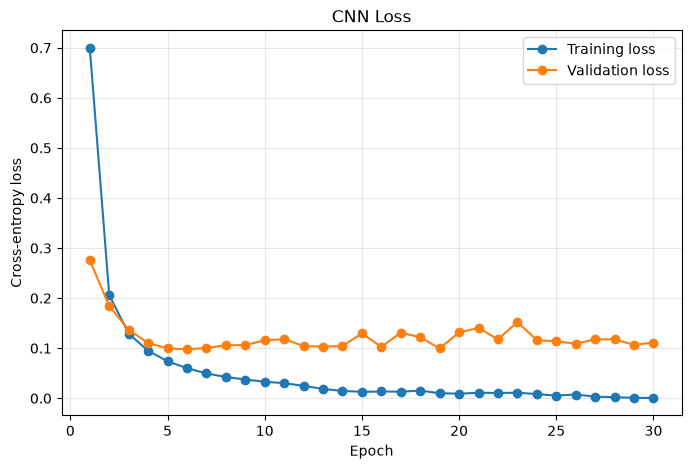

In [55]:
#a decreasing loss indicates that the CNN is improving its predictions.

epoch_numbers = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    epoch_numbers,
    history.history["loss"],
    marker="o",
    label="Training loss"
)
plt.plot(
    epoch_numbers,
    history.history["val_loss"],
    marker="o",
    label="Validation loss"
)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("CNN Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 10] plot training and validation accuracy

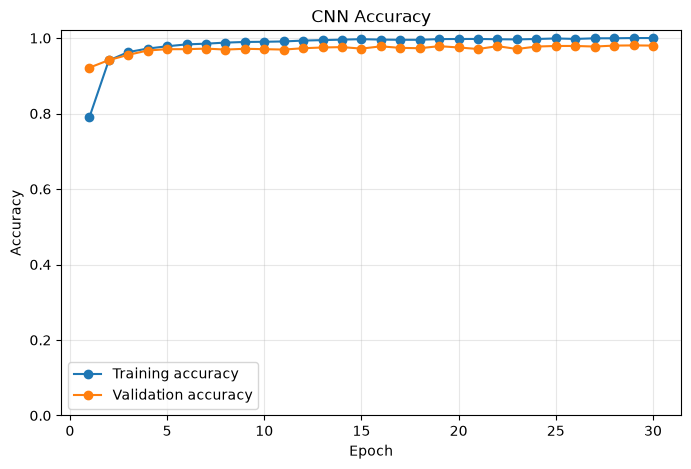

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(
    epoch_numbers,
    history.history["accuracy"],
    marker="o",
    label="Training accuracy"
)
plt.plot(
    epoch_numbers,
    history.history["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 11] evaluate the CNN on test images

In [58]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

result_table = pd.DataFrame({
    "Measure": ["Test Loss", "Test Accuracy"],
    "Value": [test_loss, test_accuracy]
})

display(result_table)


,Measure,Value
0,Test Loss,0.129152
1,Test Accuracy,0.972000


## 12] generate probabilities

In [59]:
probabilities = model.predict(
    x_test,
    verbose=0)

predicted_labels = np.argmax(
    probabilities,
    axis=1)

prediction_confidence = np.max(
    probabilities,
    axis=1)

prediction_table = pd.DataFrame({
    "Actual digit": y_test[:15],
    "Predicted digit": predicted_labels[:15],
    "Confidence": prediction_confidence[:15],
    "Correct": y_test[:15] == predicted_labels[:15]
})

display(prediction_table)

,Actual digit,Predicted digit,Confidence,Correct
0,7,7,1.000000,True
1,2,2,1.000000,True
2,1,1,1.000000,True
3,0,0,1.000000,True
4,4,4,0.999989,True
5,1,1,1.000000,True
6,4,4,0.999992,True
7,9,9,1.000000,True
8,5,5,0.999995,True
9,9,9,1.000000,True


## 13] confusion matrix / heatmap

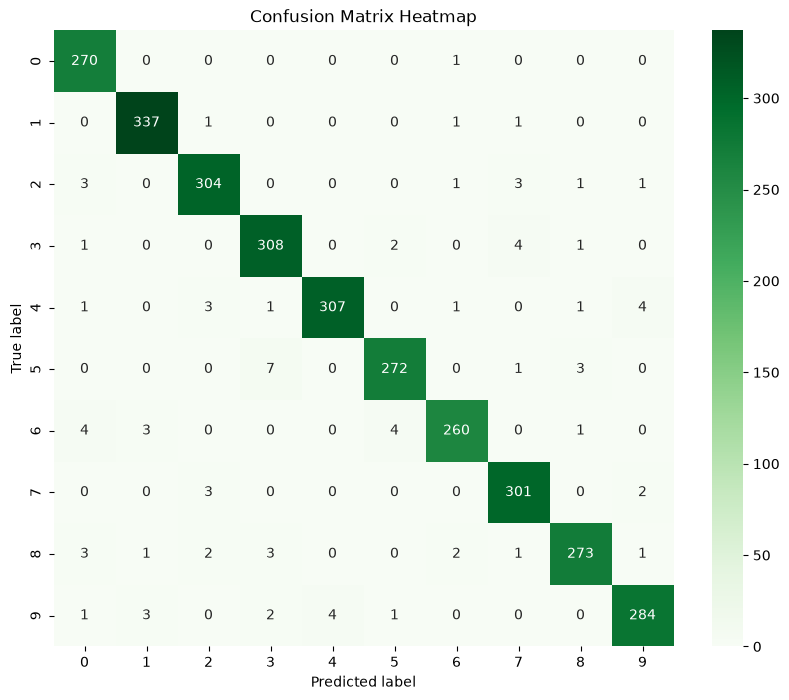

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Greens",
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## 14] visualize sample predictions

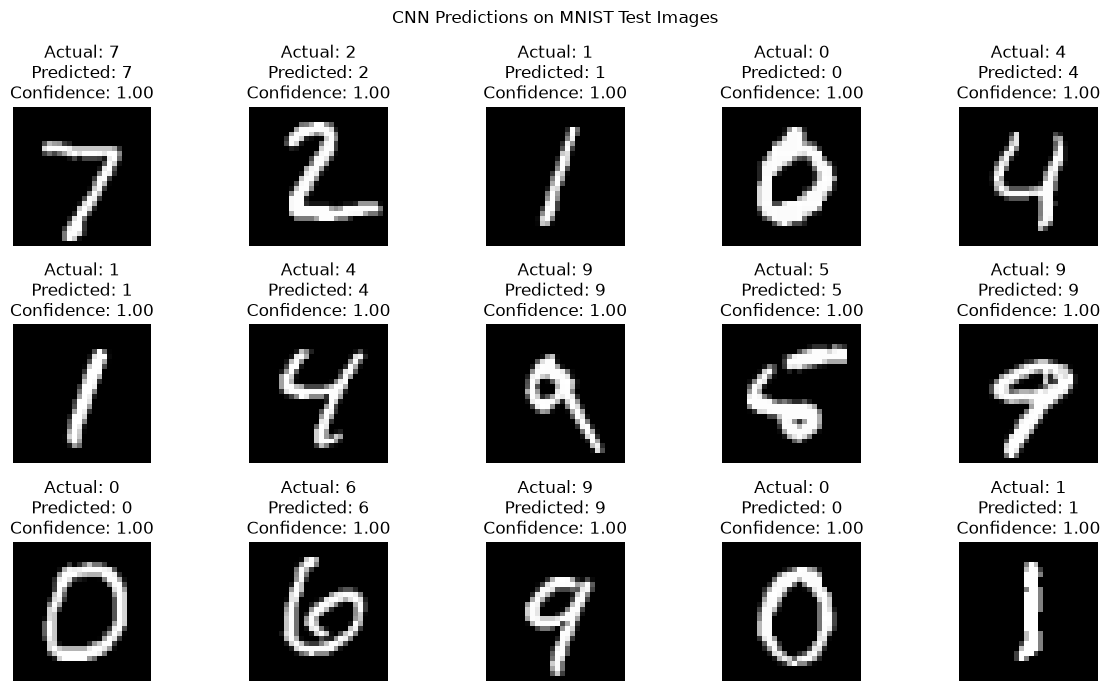

In [60]:
plt.figure(figsize=(12, 7))

for position in range(15):
    plt.subplot(3, 5, position + 1)
    plt.imshow(
        x_test[position].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[position]}\n"
        f"Predicted: {predicted_labels[position]}\n"
        f"Confidence: {prediction_confidence[position]:.2f}"
    )
    plt.axis("off")

plt.suptitle("CNN Predictions on MNIST Test Images")
plt.tight_layout()
plt.show()

***